In [9]:
!pip install "pandas==2.2.2" "numpy<2.1" atoti sqlalchemy psycopg2-binary -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 846.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 MB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
atoti-client-parquet 0.9.14 requires atoti-client==0.9.14, but you have atoti-client 0.9.1 which is incompatible.
atoti-server-parquet 0.9.14 requires atoti-core==0.9.14, but you have atoti-core 0.9.1 which is incompatible.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
import json
from datetime import datetime
import atoti as tt
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

Welcome to Atoti 0.9.1!

By using this community edition, you agree with the license available at https://docs.atoti.io/latest/eula.html.
Browse the official documentation at https://docs.atoti.io.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.


In [3]:
CSV_PATH = "/content/UNCTAD_DE_WIDEF.csv"

In [4]:
ASEAN_CODES = {
    'BRN': 'Brunei Darussalam',
    'KHM': 'Cambodia',
    'IDN': 'Indonesia',
    'LAO': 'Lao PDR',
    'MYS': 'Malaysia',
    'MMR': 'Myanmar',
    'PHL': 'Philippines',
    'SGP': 'Singapore',
    'THA': 'Thailand',
    'VNM': 'Viet Nam'
} #code ISO untuk 10 negara ASEAN

In [6]:
TRADE_INDICATORS = [
    'UNCTAD_DE_DIG_SERVTRADE_ANN_EXP',
    'UNCTAD_DE_DIG_SERVTRADE_ANN_IMP'
] #digunakan untuk ekspor & impor jasa digital

In [5]:
YEAR_COLS_ALL = [str(y) for y in range(2010, 2024)]
YEAR_COLS_FOCUS = [str(y) for y in range(2019, 2024)] #fokus analisis

In [7]:
print(f"Periode raw: 2010–2023 ({len(YEAR_COLS_ALL)} tahun)")
print(f"Periode target: 2019–2023 ({len(YEAR_COLS_FOCUS)} tahun)")
print(f"Negara ASEAN: {list(ASEAN_CODES.keys())}")

Periode raw: 2010–2023 (14 tahun)
Periode target: 2019–2023 (5 tahun)
Negara ASEAN: ['BRN', 'KHM', 'IDN', 'LAO', 'MYS', 'MMR', 'PHL', 'SGP', 'THA', 'VNM']


# Load Data

In [11]:
df_raw = pd.read_csv(CSV_PATH)

In [12]:
staging_log = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'), #waktu ekstraksi
    'source': 'UNCTAD_DE_WIDEF.csv (World Bank Data360 / UNCTADstat)',
    'total_rows': df_raw.shape[0],
    'total_cols': df_raw.shape[1],
    'negara_unik': df_raw['REF_AREA'].nunique(),
    'indikator_unik': df_raw['INDICATOR'].nunique(),
    'status': 'SUCCESS'
} #catat metadata ekstraksi sebagai audit trail

for k, v in staging_log.items():
    print(f"{k:<20}: {v}")

print(f"\nKolom: {df_raw.columns.tolist()}")
df_raw.head(3)

timestamp           : 2026-05-28 01:49:23
source              : UNCTAD_DE_WIDEF.csv (World Bank Data360 / UNCTADstat)
total_rows          : 1042
total_cols          : 32
negara_unik         : 204
indikator_unik      : 14
status              : SUCCESS

Kolom: ['FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']


,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,AGG_METHOD,AGG_METHOD_LABEL,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,Annual,ABW,Aruba,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,USD,US dollars,SUM,Sum,UNCTAD_DE,Digital Economy and Technology,6,Millions,A,Normal value,PU,Public,83.00,96.00,104.00,73.00,75.00,82.00,83.00,72.00,84.00,95.00,125.00,119.00,126.00,137.00
1,A,Annual,ABW,Aruba,UNCTAD_DE_DIG_SERVTRADE_ANN_IMP,International imports in digitally-deliverable...,USD,US dollars,SUM,Sum,UNCTAD_DE,Digital Economy and Technology,6,Millions,A,Normal value,PU,Public,270.00,291.00,336.00,353.00,411.00,375.00,404.00,405.00,435.00,427.00,359.00,442.00,489.00,525.00
2,A,Annual,AFG,Afghanistan,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,USD,US dollars,SUM,Sum,UNCTAD_DE,Digital Economy and Technology,6,Millions,A,Normal value,PU,Public,818.00,"1,066.00",638.00,296.00,456.00,311.00,176.00,170.00,249.00,214.00,375.00,NaN,NaN,NaN


# EDA

Data Mentah

In [13]:
#statistik
print(f"Total baris: {df_raw.shape[0]:,}")
print(f"Total kolom: {df_raw.shape[1]}")
print(f"Negara/wilayah unik: {df_raw['REF_AREA'].nunique()}")
print(f"Indikator unik: {df_raw['INDICATOR'].nunique()}")
print(f"Frekuensi: {df_raw['FREQ_LABEL'].unique()}")

Total baris: 1,042
Total kolom: 32
Negara/wilayah unik: 204
Indikator unik: 14
Frekuensi: ['Annual']


In [14]:
#daftar indikator
print("Daftar Indikator:")
for ind, cnt in df_raw['INDICATOR'].value_counts().items():
    label = df_raw[df_raw['INDICATOR'] == ind]['INDICATOR_LABEL'].iloc[0][:55]
    unit = df_raw[df_raw['INDICATOR'] == ind]['UNIT_MEASURE_LABEL'].iloc[0]
    print(f"[{cnt:>4} baris] {ind} | {unit}")

Daftar Indikator:
[ 203 baris] UNCTAD_DE_DIG_SERVTRADE_ANN_IMP | US dollars
[ 200 baris] UNCTAD_DE_DIG_SERVTRADE_ANN_EXP | US dollars
[  69 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B3 | Percentage of businesses
[  67 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B5 | Percentage of businesses
[  65 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B1 | Percentage of businesses
[  64 baris] UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B7 | Percentage of businesses
[  64 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B8 | Percentage of businesses
[  55 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B4 | Percentage of employees
[  54 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B2 | Percentage of employees
[  54 baris] UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B6 | Percentage of businesses
[  52 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B10 | Percentage of businesses
[  49 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B11 | Percentage of businesses
[  23 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B12_IDEL | Percentage of businesses
[  23 baris] UNCTAD_DE_ICT_COR

In [15]:
#sparsity global, berapa persen sel kosong
total_cells = df_raw.shape[0] * len(YEAR_COLS_ALL)
miss_cells = df_raw[YEAR_COLS_ALL].isnull().sum().sum()
sparsity_pct = miss_cells / total_cells * 100

print(f"Kombinasi (baris × {len(YEAR_COLS_ALL)} tahun): {total_cells:,}")
print(f"Sel kosong: {miss_cells:,}")
print(f"Global sparsity: {sparsity_pct:.1f}%")

Kombinasi (baris × 14 tahun): 14,588
Sel kosong: 6,897
Global sparsity: 47.3%


In [16]:
#sparsity per indikator
print("Sparsity per Indikator")
for ind, grp in df_raw.groupby('INDICATOR'):
    tot = grp.shape[0] * len(YEAR_COLS_ALL)
    mis = grp[YEAR_COLS_ALL].isnull().sum().sum()
    cat = 'ICT' if 'ICT' in ind else 'TRADE'
    print(f"[{cat}] {ind[-30:]:<32} = {mis/tot*100:.1f}% missing")

Sparsity per Indikator
[TRADE] NCTAD_DE_DIG_SERVTRADE_ANN_EXP   = 6.8% missing
[TRADE] NCTAD_DE_DIG_SERVTRADE_ANN_IMP   = 6.9% missing
[ICT] TAD_DE_ICT_CORE_UBS_ANN_ALL_B1   = 66.5% missing
[ICT] AD_DE_ICT_CORE_UBS_ANN_ALL_B10   = 87.0% missing
[ICT] _ICT_CORE_UBS_ANN_ALL_B12_IDEL   = 81.4% missing
[ICT] TAD_DE_ICT_CORE_UBS_ANN_ALL_B2   = 70.0% missing
[ICT] TAD_DE_ICT_CORE_UBS_ANN_ALL_B3   = 67.1% missing
[ICT] DE_ICT_CORE_UISIC3N1_ANN_00_B6   = 85.7% missing
[ICT] DE_ICT_CORE_UISIC3N1_ANN_00_B7   = 65.6% missing
[ICT] _DE_ICT_CORE_UISIC4_ANN_00_B11   = 87.2% missing
[ICT] T_CORE_UISIC4_ANN_00_B12_ICUST   = 80.1% missing
[ICT] D_DE_ICT_CORE_UISIC4_ANN_00_B4   = 66.1% missing
[ICT] D_DE_ICT_CORE_UISIC4_ANN_00_B5   = 66.5% missing
[ICT] D_DE_ICT_CORE_UISIC4_ANN_00_B8   = 68.0% missing


# EDA ASEAN

In [17]:
df_asean_all = df_raw[df_raw['REF_AREA'].isin(ASEAN_CODES.keys())].copy() #filter hanya 10 negara asean

In [18]:
print("Data ASEAN di Dataset (sebelum filter ICT)")
print(f"Total baris ASEAN: {df_asean_all.shape[0]}")
print(f"Indikator yang ada:")
print(df_asean_all['INDICATOR'].value_counts().to_string())

Data ASEAN di Dataset (sebelum filter ICT)
Total baris ASEAN: 79
Indikator yang ada:
INDICATOR
UNCTAD_DE_DIG_SERVTRADE_ANN_EXP               10
UNCTAD_DE_DIG_SERVTRADE_ANN_IMP               10
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B3              7
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B5            7
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B1              6
UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B7          5
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B8            5
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B10             5
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B12_IDEL        5
UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B6          5
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B12_ICUST     4
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B11           4
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B2              3
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B4            3


In [19]:
print("Berapa negara ASEAN punya data ICT pada Rentang 2019-2023")
ict_df = df_asean_all[df_asean_all['INDICATOR'].str.contains('ICT')]
negara_dengan_ict = set()
for _, row in ict_df.iterrows():
    vals = row[YEAR_COLS_FOCUS].dropna()
    if len(vals) > 0:
        negara_dengan_ict.add(row['REF_AREA_LABEL'])

print(f"Negara dengan ≥1 data ICT: {len(negara_dengan_ict)} dari 10")
print(f"Negara dengan dat ICT: {negara_dengan_ict}")

Berapa negara ASEAN punya data ICT pada Rentang 2019-2023
Negara dengan ≥1 data ICT: 4 dari 10
Negara dengan dat ICT: {'Thailand', 'Malaysia', 'Philippines', 'Indonesia'}


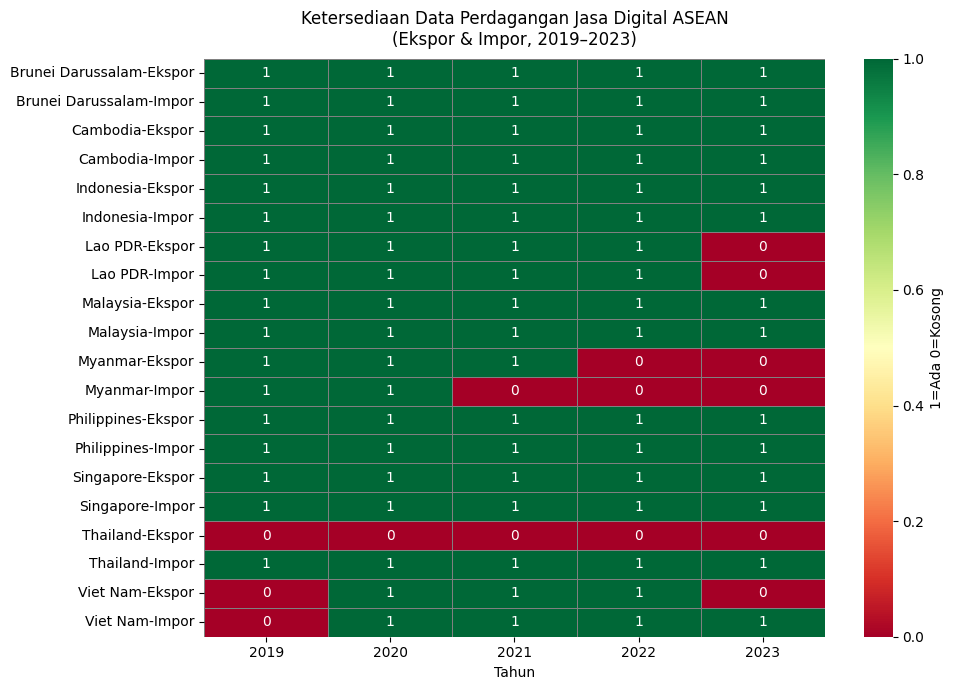

In [20]:
trade_asean = df_asean_all[df_asean_all['INDICATOR'].isin(TRADE_INDICATORS)].copy() #filter hanya trade untuk heatmap

rows_heat = []
for _, row in trade_asean.iterrows():
    for yr in YEAR_COLS_FOCUS:
        rows_heat.append({
            'negara': row['REF_AREA_LABEL'],
            'indikator': 'Ekspor' if 'EXP' in row['INDICATOR'] else 'Impor',
            'tahun': int(yr),
            'ada': 0 if pd.isnull(row[yr]) else 1,
            'nilai': row[yr]
        })
df_heat = pd.DataFrame(rows_heat) #tabel biner ada atau tidaknya data per negara per tahun

pivot_h = df_heat.pivot_table( index=['negara', 'indikator'], columns='tahun', values='ada', aggfunc='max').fillna(0)

#heatmap ketersediaan data
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_h, cmap='RdYlGn', linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1, cbar_kws={'label': '1=Ada 0=Kosong'},
            annot=True, fmt='.0f', ax=ax)
ax.set_title('Ketersediaan Data Perdagangan Jasa Digital ASEAN\n' '(Ekspor & Impor, 2019–2023)', fontsize=12, pad=10)
ax.set_xlabel('Tahun'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [21]:
#sparsity data di asean
print("Sparsity Subset ASEAN 2019-2023")
total_ideal = 10 * 2 * 5 #10 negara x 2 indikator x 5 tahun
data_ada = df_heat[df_heat['ada'] == 1].shape[0]
data_kosong = total_ideal - data_ada
sparse_asean = data_kosong / total_ideal * 100
print(f"Kombinasi ideal (10×2×5): {total_ideal}")
print(f"Data tersedia: {data_ada}")
print(f"Data kosong: {data_kosong}")
print(f"Sparsity subset ASEAN: {sparse_asean:.1f}%")

Sparsity Subset ASEAN 2019-2023
Kombinasi ideal (10×2×5): 100
Data tersedia: 85
Data kosong: 15
Sparsity subset ASEAN: 15.0%


In [22]:
print("Kelengkapan per negara:")
kelengkapan = df_heat.groupby('negara')['ada'].agg(['sum', 'count'])
kelengkapan['persen'] = kelengkapan['sum'] / kelengkapan['count'] * 100
kelengkapan.columns = ['Ada', 'Total', '%Lengkap']
kelengkapan = kelengkapan.sort_values('%Lengkap', ascending=False)
print(kelengkapan.to_string())

Kelengkapan per negara:
                   Ada  Total  %Lengkap
negara                                 
Brunei Darussalam   10     10    100.00
Cambodia            10     10    100.00
Indonesia           10     10    100.00
Malaysia            10     10    100.00
Singapore           10     10    100.00
Philippines         10     10    100.00
Lao PDR              8     10     80.00
Viet Nam             7     10     70.00
Myanmar              5     10     50.00
Thailand             5     10     50.00


# Singapore Effect

In [23]:
rows_eda = []
for _, row in trade_asean.iterrows():
    tipe = 'Ekspor' if 'EXP' in row['INDICATOR'] else 'Impor'
    for yr in YEAR_COLS_FOCUS:
        if not pd.isnull(row[yr]): #hanya ambil baris yang ada nilainya
            rows_eda.append({
                'negara': row['REF_AREA_LABEL'],
                'kode': row['REF_AREA'],
                'tipe': tipe,
                'tahun': int(yr),
                'nilai': row[yr]
            })
df_eda = pd.DataFrame(rows_eda)

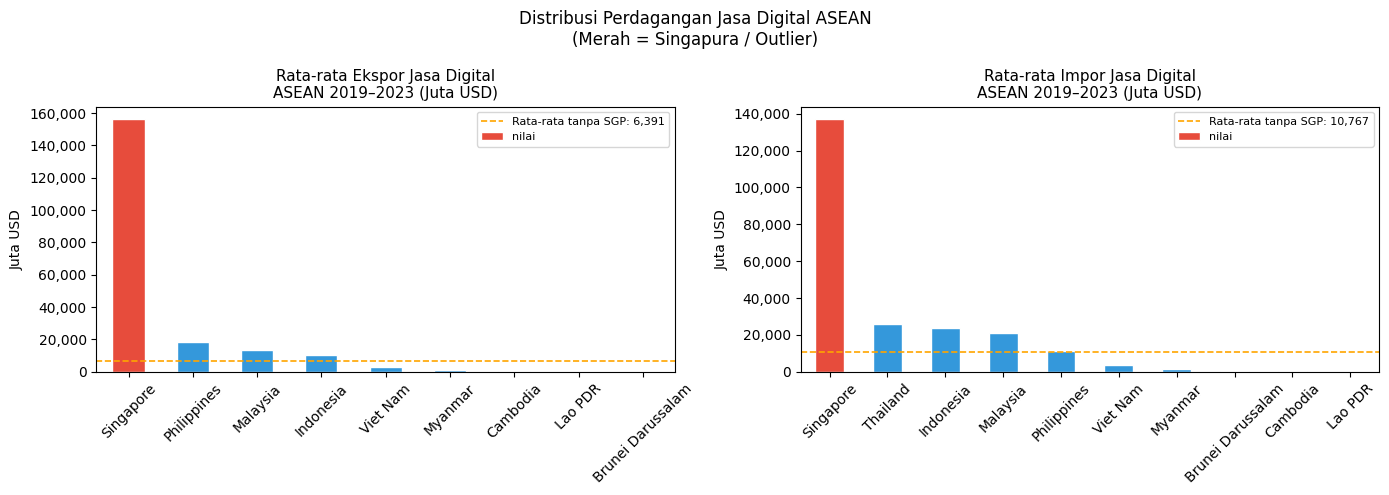

In [24]:
#plot bar rata-rata per negara, singapura sebagai outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tipe in zip(axes, ['Ekspor', 'Impor']):
    sub = df_eda[df_eda['tipe'] == tipe]
    mean_neg = sub.groupby('negara')['nilai'].mean().sort_values(ascending=False)
    colors = ['#e74c3c' if c == 'Singapore' else '#3498db' for c in mean_neg.index]
    mean_neg.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Rata-rata {tipe} Jasa Digital\nASEAN 2019–2023 (Juta USD)', fontsize=11)
    ax.set_ylabel('Juta USD')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    avg_ex_sgp = sub[sub['negara'] != 'Singapore']['nilai'].mean()
    ax.axhline(avg_ex_sgp, color='orange', linestyle='--', linewidth=1.2, label=f'Rata-rata tanpa SGP: {avg_ex_sgp:,.0f}')
    ax.legend(fontsize=8)

fig.suptitle('Distribusi Perdagangan Jasa Digital ASEAN\n(Merah = Singapura / Outlier)', fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
print("Rasio Singapura vs Rata-rata Negara Lain")
for tipe in ['Ekspor', 'Impor']:
    sub = df_eda[df_eda['tipe'] == tipe]
    sgp = sub[sub['kode'] == 'SGP']['nilai'].mean()
    others = sub[sub['kode'] != 'SGP']['nilai'].mean()
    if not np.isnan(sgp):
        print(f"{tipe}: SGP={sgp:>12,.1f} lainnya={others:>10,.1f} " f"rasio={sgp/others:.0f}× lebih tinggi")

Rasio Singapura vs Rata-rata Negara Lain
Ekspor: SGP=   156,221.8 lainnya=   6,390.7 rasio=24× lebih tinggi
Impor: SGP=   137,033.6 lainnya=  10,766.9 rasio=13× lebih tinggi


# Cleaning

In [26]:
konstan_cols = [c for c in df_raw.columns if df_raw[c].nunique(dropna=False) <= 1 and c not in YEAR_COLS_ALL] #kolom yang isinya konstan/tidak informatif utuk dihapus, kecuali kolom tahun
print(f"Kolom konstan/dummy ditemukan: {konstan_cols}")

df_clean = df_raw.copy()

Kolom konstan/dummy ditemukan: ['FREQ', 'FREQ_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']


In [27]:
df_clean = df_clean.drop(columns=konstan_cols, errors='ignore') #hapus kolom konstan

In [28]:
#hapus baris yang duplikat
n_before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Duplikat dihapus: {n_before - df_clean.shape[0]} baris")

Duplikat dihapus: 0 baris


In [29]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].replace( ['Not Available', 'NA', 'N/A', '', ' '], np.nan) #ganti null menjadi nan

print(f"Shape setelah cleansing: {df_clean.shape}")

Shape setelah cleansing: (1042, 24)


# Standarisasi

In [30]:
#seragamkan format teks
df_clean['REF_AREA'] = df_clean['REF_AREA'].str.strip().str.upper()
df_clean['REF_AREA_LABEL'] = df_clean['REF_AREA_LABEL'].str.strip()
df_clean['INDICATOR'] = df_clean['INDICATOR'].str.strip()

In [31]:
for yr in YEAR_COLS_ALL:
    if yr in df_clean.columns:
        df_clean[yr] = pd.to_numeric(df_clean[yr], errors='coerce') #convert kolom tahun ke numerik

In [32]:
if 'AGG_METHOD' in df_clean.columns:
    df_clean['AGG_METHOD'] = df_clean['AGG_METHOD'].fillna('SUM') #isi agg method yangg kosong dengan sum

# Transform

In [33]:
df_filtered = df_clean[ (df_clean['REF_AREA'].isin(ASEAN_CODES.keys())) & (df_clean['INDICATOR'].isin(TRADE_INDICATORS))].copy() #filter kawasan asean dan indikator trade

In [39]:
df_long = df_filtered.melt(
    id_vars=['REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE', 'AGG_METHOD', 'UNIT_MULT'], #identitas
    value_vars=YEAR_COLS_ALL, #kolom tahun yang di melt
    var_name='TIME_PERIOD', #nama kolom hasil melt
    value_name='OBS_VALUE'
) #ubah format wide ke long agar sesuai dengan struktur tabel fact
df_long['TIME_PERIOD'] = df_long['TIME_PERIOD'].astype(int) #tahun ke integer

In [40]:
df_long = df_long[df_long['TIME_PERIOD'].between(2019, 2023)].copy() #filter ke rentang 2019-2023
df_long = df_long.reset_index(drop=True)

print(f"Shape long format (2019-2023): {df_long.shape}")
print(f"Missing OBS_VALUE: {df_long['OBS_VALUE'].isnull().sum()}" f"({df_long['OBS_VALUE'].isnull().mean()*100:.1f}%)")

Shape long format (2019-2023): (100, 9)
Missing OBS_VALUE: 15(15.0%)


In [41]:
#integrasi atribut baru
df_long['kawasan'] = 'ASEAN' #label kawasan untuk hierarki olap
df_long['periode'] = '2019-2023' #periode analisis
df_long['tipe'] = df_long['INDICATOR'].apply( lambda x: 'Ekspor' if 'EXP' in x else 'Impor') #transaksi
df_long['unit_type'] = df_long['UNIT_MEASURE'].apply( lambda x: 'Currency' if str(x) == 'USD' else 'Ratio')

In [42]:
#dimensi geografis dengan surrogate key
dim_negara = (df_long[['REF_AREA', 'REF_AREA_LABEL']].drop_duplicates().reset_index(drop=True))
dim_negara.insert(0, 'id_negara', range(1, len(dim_negara) + 1))
dim_negara.columns = ['id_negara', 'ref_area', 'ref_area_label']
dim_negara['kawasan'] = 'ASEAN'

In [43]:
#dimensi temporal dengan surrogate key
dim_waktu = pd.DataFrame({'time_period': sorted(df_long['TIME_PERIOD'].unique())})
dim_waktu.insert(0, 'id_waktu', range(1, len(dim_waktu) + 1))
dim_waktu['periode'] = '2019-2023'

In [44]:
#dimensi jenis indikator ekonomi digital
dim_indikator = (df_long[['INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE', 'UNIT_MULT', 'AGG_METHOD', 'unit_type']].drop_duplicates().reset_index(drop=True))
dim_indikator.insert(0, 'id_indikator', range(1, len(dim_indikator) + 1))
dim_indikator.columns = ['id_indikator', 'indicator', 'indicator_label', 'unit_measure', 'unit_mult', 'agg_method', 'unit_type']

In [45]:
df_fact = (df_long.merge(dim_negara[['ref_area','id_negara']].rename(columns={'ref_area':'REF_AREA'}), on='REF_AREA').merge(dim_waktu[['time_period','id_waktu']].rename(columns={'time_period':'TIME_PERIOD'}), on='TIME_PERIOD').merge(dim_indikator[['indicator','id_indikator']].rename(columns={'indicator':'INDICATOR'}), on='INDICATOR')) #tabel fakta hasil join dimensi untuk dapatkan surrogate key, lalu ambil kolom yang dibutuhkan

In [46]:
#tabel fakta berisi foreign key dan measure utama
fact = df_fact[['id_negara','id_waktu','id_indikator','OBS_VALUE']].copy()
fact.columns = ['id_negara','id_waktu','id_indikator','obs_value']
fact = fact.reset_index(drop=True)
fact.insert(0, 'id_perdagangan', range(1, len(fact) + 1))

# Load ke PostgreSQL

In [47]:
from sqlalchemy import create_engine, text

In [ ]:
DATABASE_URL = "postgresql://neondb_owner:your_password" #connection string neon

In [52]:
try:
    engine = create_engine(DATABASE_URL) #koneksi ke db

    with engine.connect() as conn:
        conn.execute(text("""
            DROP TABLE IF EXISTS fact_perdagangan_jasa_digital CASCADE;
            DROP TABLE IF EXISTS dim_negara CASCADE;
            DROP TABLE IF EXISTS dim_waktu CASCADE;
            DROP TABLE IF EXISTS dim_indikator CASCADE;
        """))
        conn.execute(text("""
            CREATE TABLE dim_negara (
                id_negara      SERIAL PRIMARY KEY,
                ref_area       VARCHAR(5)   NOT NULL,
                ref_area_label VARCHAR(100),
                kawasan        VARCHAR(50)  DEFAULT 'ASEAN'
            );
            CREATE TABLE dim_waktu (
                id_waktu    SERIAL PRIMARY KEY,
                time_period INT  NOT NULL,
                periode     VARCHAR(20)
            );
            CREATE TABLE dim_indikator (
                id_indikator    SERIAL PRIMARY KEY,
                indicator       VARCHAR(60)  NOT NULL,
                indicator_label TEXT,
                unit_measure    VARCHAR(20),
                unit_mult       VARCHAR(20),
                unit_type       VARCHAR(20),
                agg_method      VARCHAR(10)
            );
            CREATE TABLE fact_perdagangan_jasa_digital (
                id_perdagangan SERIAL PRIMARY KEY,
                id_negara      INT REFERENCES dim_negara(id_negara),
                id_waktu       INT REFERENCES dim_waktu(id_waktu),
                id_indikator   INT REFERENCES dim_indikator(id_indikator),
                obs_value      NUMERIC(18,2)
            );
        """))
        conn.commit()
        print("Tabel berhasil dibuat")

    dim_negara.to_sql('dim_negara', engine, if_exists='append', index=False)
    dim_waktu.to_sql('dim_waktu', engine, if_exists='append', index=False)
    dim_indikator.to_sql('dim_indikator', engine, if_exists='append', index=False)
    fact.to_sql('fact_perdagangan_jasa_digital', engine, if_exists='append', index=False)
    print("Data berhasil dimuat")

    with engine.connect() as conn:
        conn.execute(text("""
            CREATE INDEX IF NOT EXISTS idx_fact_negara
                ON fact_perdagangan_jasa_digital(id_negara);
            CREATE INDEX IF NOT EXISTS idx_fact_waktu
                ON fact_perdagangan_jasa_digital(id_waktu);
            CREATE INDEX IF NOT EXISTS idx_fact_indikator
                ON fact_perdagangan_jasa_digital(id_indikator);
        """))

        conn.execute(text("""
            CREATE MATERIALIZED VIEW IF NOT EXISTS mv_trade_summary AS
            SELECT
                n.ref_area_label  AS negara,
                n.kawasan,
                w.time_period     AS tahun,
                i.indicator_label AS jenis_perdagangan,
                i.unit_type,
                SUM(f.obs_value)  AS total_nilai_juta_usd
            FROM fact_perdagangan_jasa_digital f
            JOIN dim_negara    n ON f.id_negara    = n.id_negara
            JOIN dim_waktu     w ON f.id_waktu     = w.id_waktu
            JOIN dim_indikator i ON f.id_indikator = i.id_indikator
            WHERE f.obs_value IS NOT NULL
            GROUP BY n.ref_area_label, n.kawasan,
                     w.time_period, i.indicator_label, i.unit_type
            WITH DATA;
        """))
        conn.commit()
        print("Index & Materialized View berhasil dibuat")

    with engine.connect() as conn:
        result = conn.execute(text("""
            SELECT
                relname AS tabel,
                pg_size_pretty(pg_total_relation_size(relid)) AS ukuran
            FROM pg_catalog.pg_statio_user_tables
            ORDER BY pg_total_relation_size(relid) DESC;
        """))
        print("Ukuran tabel di DB:")
        for row in result:
            print(f"{row[0]:<45} {row[1]}")

except Exception as e:
    print(f"Koneksi DB gagal: {e}")

Tabel berhasil dibuat
Data berhasil dimuat
Index & Materialized View berhasil dibuat
Ukuran tabel di DB:
fact_perdagangan_jasa_digital                 72 kB
dim_indikator                                 32 kB
mv_trade_summary                              32 kB
dim_negara                                    24 kB
dim_waktu                                     24 kB


# OLAP

In [58]:
df_olap = fact.merge(dim_negara, on='id_negara') \
              .merge(dim_waktu, on='id_waktu') \
              .merge(dim_indikator, on='id_indikator') #menggabungkan tabel fakta dengan semua dimensi

df_olap['tipe'] = df_olap['indicator'].apply( lambda x: 'Ekspor' if 'EXP' in x else 'Impor')
df_olap['tahun'] = df_olap['time_period']
df_olap['negara'] = df_olap['ref_area_label']

In [59]:
#total nilai per negara per tipe
olap1 = (df_olap.groupby(['ref_area_label','tipe'])['obs_value'].sum().reset_index())
olap1.columns = ['negara','tipe','Total Nilai (Juta USD)']
print("Total per Negara:")
print(olap1.to_string(index=False))

Total per Negara:
           negara   tipe  Total Nilai (Juta USD)
Brunei Darussalam Ekspor                   82.00
Brunei Darussalam  Impor                2,652.00
         Cambodia Ekspor                1,023.00
         Cambodia  Impor                2,369.00
        Indonesia Ekspor               52,500.00
        Indonesia  Impor              118,296.00
          Lao PDR Ekspor                  194.00
          Lao PDR  Impor                  254.00
         Malaysia Ekspor               66,101.00
         Malaysia  Impor              104,227.00
          Myanmar Ekspor                2,674.00
          Myanmar  Impor                2,658.00
      Philippines Ekspor               92,990.00
      Philippines  Impor               56,534.00
        Singapore Ekspor              781,109.00
        Singapore  Impor              685,168.00
         Thailand Ekspor                    0.00
         Thailand  Impor              128,665.00
         Viet Nam Ekspor                8,112.00
  

In [60]:
#tren total kawasann asean per tahun
olap2 = (df_olap.groupby(['tahun','tipe'])['obs_value'].sum().reset_index())
olap2.columns = ['tahun','tipe','Total Nilai (Juta USD)']
print("Tren Kawasan per Tahun:")
print(olap2.to_string(index=False))

Tren Kawasan per Tahun:
 tahun   tipe  Total Nilai (Juta USD)
  2019 Ekspor              163,665.00
  2019  Impor              178,286.00
  2020 Ekspor              173,756.00
  2020  Impor              192,684.00
  2021 Ekspor              203,932.00
  2021  Impor              224,628.00
  2022 Ekspor              225,031.00
  2022  Impor              250,422.00
  2023 Ekspor              238,401.00
  2023  Impor              269,825.00


In [61]:
#drill down kawasan, negara, tahun, dan tipe
olap3 = (df_olap.groupby(['kawasan','ref_area_label','tahun','tipe'])['obs_value'].sum().reset_index())
olap3.columns = ['kawasan','negara','tahun','tipe','Total Nilai (Juta USD)']

In [62]:
#hitung neraca impor, ekspor per negara
pivot_sd = olap1.pivot(index='negara', columns='tipe', values='Total Nilai (Juta USD)')
if 'Ekspor' in pivot_sd.columns and 'Impor' in pivot_sd.columns:
    pivot_sd['Neraca'] = pivot_sd['Ekspor'] - pivot_sd['Impor']
    pivot_sd['Status'] = pivot_sd['Neraca'].apply(lambda x: 'Surplus' if x > 0 else ('Defisit' if x < 0 else '—') if not np.isnan(x) else '—')
print("Surplus/Defisit:")
print(pivot_sd.to_string())

Surplus/Defisit:
tipe                  Ekspor      Impor      Neraca   Status
negara                                                      
Brunei Darussalam      82.00   2,652.00   -2,570.00  Defisit
Cambodia            1,023.00   2,369.00   -1,346.00  Defisit
Indonesia          52,500.00 118,296.00  -65,796.00  Defisit
Lao PDR               194.00     254.00      -60.00  Defisit
Malaysia           66,101.00 104,227.00  -38,126.00  Defisit
Myanmar             2,674.00   2,658.00       16.00  Surplus
Philippines        92,990.00  56,534.00   36,456.00  Surplus
Singapore         781,109.00 685,168.00   95,941.00  Surplus
Thailand                0.00 128,665.00 -128,665.00  Defisit
Viet Nam            8,112.00  15,022.00   -6,910.00  Defisit


In [64]:
#rata-rata impor & ekspor
olap_avg = (df_olap.groupby(['ref_area_label','tipe'])['obs_value'].mean().reset_index())
olap_avg.columns = ['negara','tipe','Rata-rata Nilai (Juta USD)']

pivot_avg = olap_avg.pivot(index='negara', columns='tipe', values='Rata-rata Nilai (Juta USD)')
pivot_avg.columns.name = None
pivot_avg = pivot_avg.round(2)
print("Rata-rata Ekspor & Impor per Negara (2019-2023, Juta USD):")
print(pivot_avg.to_string())

Rata-rata Ekspor & Impor per Negara (2019-2023, Juta USD):
                      Ekspor      Impor
negara                                 
Brunei Darussalam      16.40     530.40
Cambodia              204.60     473.80
Indonesia          10,500.00  23,659.20
Lao PDR                48.50      63.50
Malaysia           13,220.20  20,845.40
Myanmar               891.33   1,329.00
Philippines        18,598.00  11,306.80
Singapore         156,221.80 137,033.60
Thailand                 NaN  25,733.00
Viet Nam            2,704.00   3,755.50


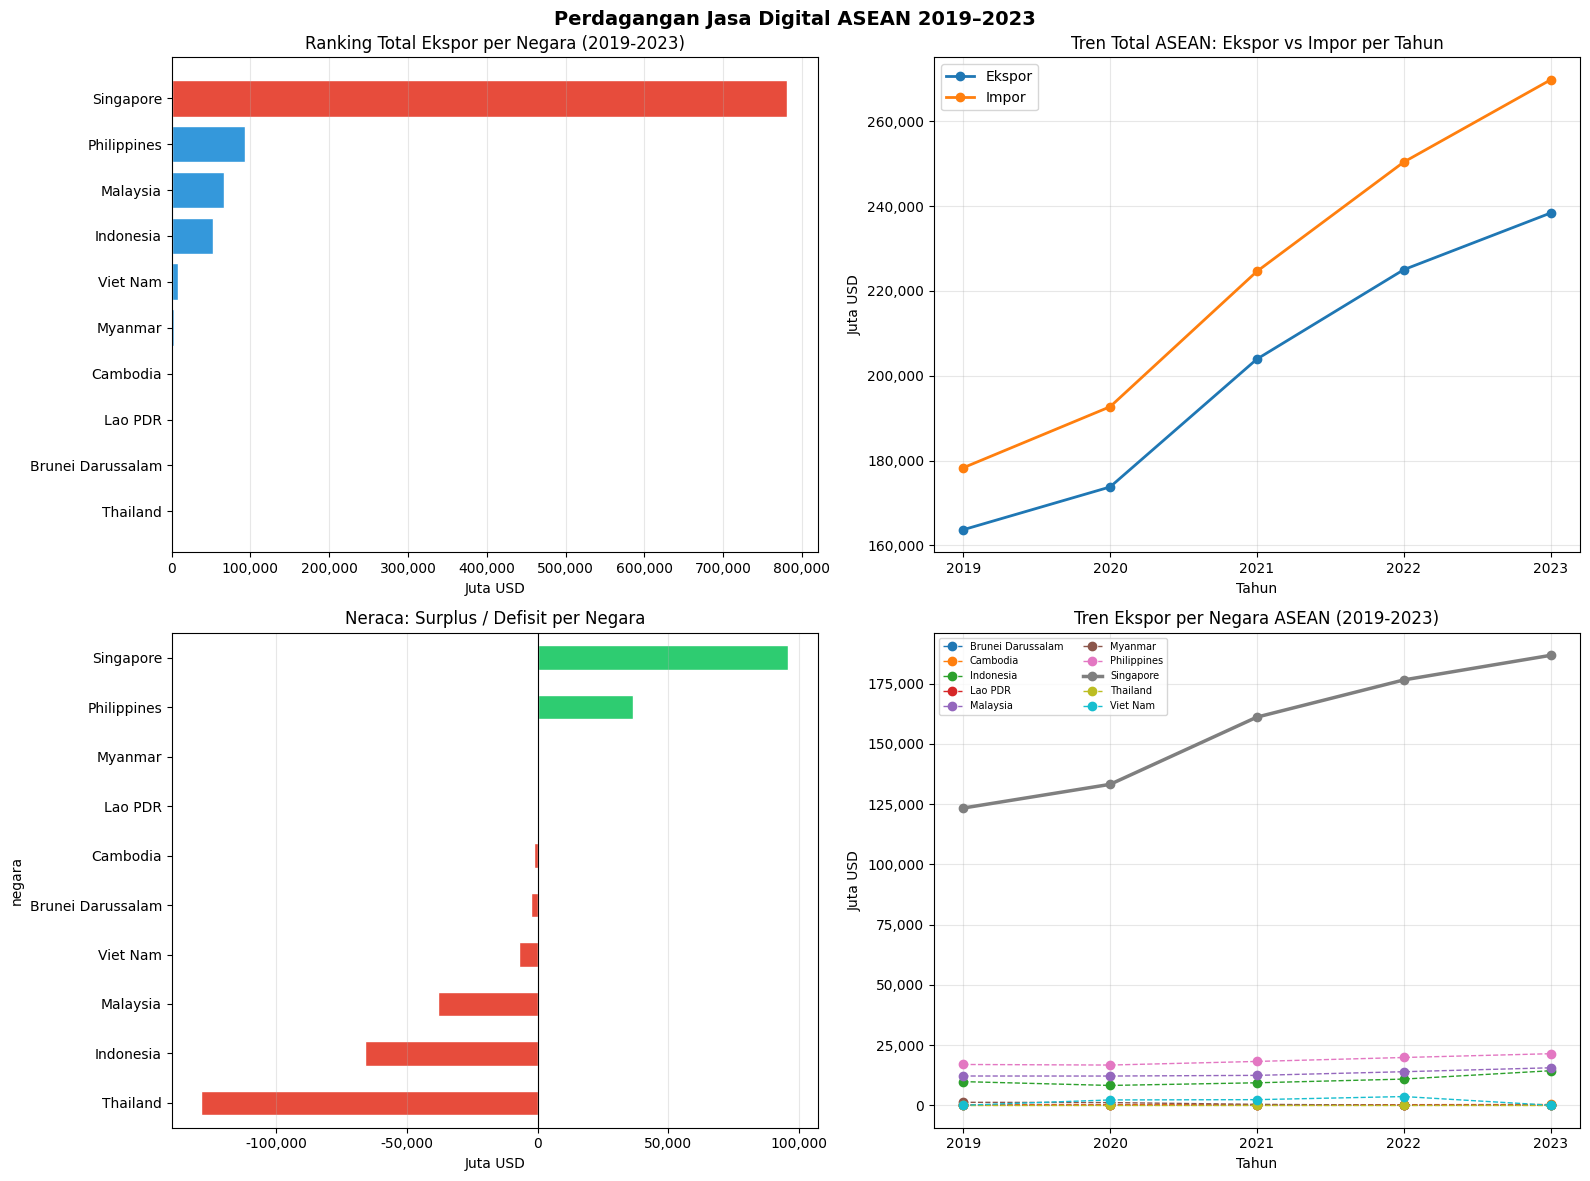

In [63]:
#visualisasi
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perdagangan Jasa Digital ASEAN 2019–2023', fontsize=14, fontweight='bold')

ax = axes[0, 0]
exp_rank = (olap1[olap1['tipe'] == 'Ekspor'].sort_values('Total Nilai (Juta USD)', ascending=True))
colors_r = ['#e74c3c' if n == 'Singapore' else '#3498db' for n in exp_rank['negara']]
ax.barh(exp_rank['negara'], exp_rank['Total Nilai (Juta USD)'], color=colors_r, edgecolor='white')
ax.set_title('Ranking Total Ekspor per Negara (2019-2023)')
ax.set_xlabel('Juta USD')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

ax = axes[0, 1]
for tipe, grp in olap2.groupby('tipe'):
    ax.plot(grp['tahun'].astype(str), grp['Total Nilai (Juta USD)'],
            marker='o', linewidth=2, label=tipe)
ax.set_title('Tren Total ASEAN: Ekspor vs Impor per Tahun')
ax.set_ylabel('Juta USD'); ax.set_xlabel('Tahun')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
neraca = pivot_sd['Neraca'].dropna().sort_values()
colors_n = ['#e74c3c' if v < 0 else '#2ecc71' for v in neraca]
neraca.plot(kind='barh', ax=ax, color=colors_n, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Neraca: Surplus / Defisit per Negara')
ax.set_xlabel('Juta USD')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

ax = axes[1, 1]
for neg, grp in olap3[olap3['tipe'] == 'Ekspor'].groupby('negara'):
    sub = grp.groupby('tahun')['Total Nilai (Juta USD)'].sum()
    lw  = 2.5 if neg == 'Singapore' else 1
    ls  = '-'  if neg == 'Singapore' else '--'
    ax.plot(sub.index.astype(str), sub.values, marker='o', label=neg, linewidth=lw, linestyle=ls)
ax.set_title('Tren Ekspor per Negara ASEAN (2019-2023)')
ax.set_ylabel('Juta USD'); ax.set_xlabel('Tahun')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()